# Claim fidelity

This notebook reproduces the claim-fidelity results in §4.3 directly from raw extraction and verification files.

In [1]:
from pathlib import Path
import json, re
from collections import Counter, defaultdict
from urllib.parse import urlparse

import pandas as pd
from IPython.display import HTML, Markdown, display

ROOT = Path.cwd()
if not (ROOT / "raw").is_dir():
    ROOT = ROOT.parent
RAW_AIOS = ROOT / "raw" / "aio_results"

CATEGORY_NAMES = {
    "autos_vehicles": "Autos & Vehicles", "beauty_fashion": "Beauty & Fashion",
    "business_finance": "Business & Finance", "climate": "Climate",
    "entertainment": "Entertainment", "food_drink": "Food & Drink",
    "games": "Games", "health": "Health", "hobbies_leisure": "Hobbies & Leisure",
    "jobs_education": "Jobs & Education", "law_gov": "Law & Government",
    "other": "Other", "pets_animals": "Pets & Animals", "politics": "Politics",
    "science": "Science", "shopping": "Shopping", "sports": "Sports",
    "technology": "Technology", "travel_transport": "Travel & Transport",
}

def category_from_path(path, root=RAW_AIOS):
    folder = path.relative_to(root).parts[1]
    slug = re.match(r"trending_US_1d_(.+?)_\d{4}-", folder).group(1)
    return CATEGORY_NAMES[slug]

def hostname(url):
    host = (urlparse(url).hostname or "").lower()
    return host[4:] if host.startswith("www.") else host

def show_table(frame, formats=None):
    output = frame.copy()
    for column, template in (formats or {}).items():
        output[column] = output[column].map(template.format)
    display(HTML(output.to_html(index=False, border=0)))
import matplotlib.pyplot as plt

LABELS = ["CLEAR", "VAGUE", "AMBIGUOUS", "INCORRECT", "OMITTED"]
UGC_ROOTS = {"facebook.com", "instagram.com", "linkedin.com", "pinterest.com", "quora.com", "reddit.com", "threads.com", "threads.net", "tiktok.com", "twitter.com", "x.com", "youtube.com"}

def is_ugc_suffix(url):
    host = hostname(url)
    return any(host == root or host.endswith("." + root) for root in UGC_ROOTS)

rows = []
zero_claims = social_only = 0
all_extracted = []
for result_path in sorted(RAW_AIOS.rglob("result.json")):
    category = category_from_path(result_path)
    result = json.loads(result_path.read_text(encoding="utf-8"))
    refs = (result.get("aiOverview") or {}).get("references") or []
    urls = [r.get("url") for r in refs if isinstance(r, dict) and r.get("url")]
    claim_path = result_path.parent / "claims_grok_4_1.json"
    claims = json.loads(claim_path.read_text(encoding="utf-8")).get("claims") or []
    all_extracted.append(len(claims))
    verdict_path = result_path.parent / "verification_result_grok-4-1-fast-reasoning_v2.json"
    if not verdict_path.exists():
        if not claims:
            zero_claims += 1
        elif urls and all(is_ugc_suffix(url) for url in urls):
            social_only += 1
        continue
    counts = Counter(str(v.get("label") or "").upper() for v in json.loads(verdict_path.read_text(encoding="utf-8")).get("verifications") or [])
    total = sum(counts[label] for label in LABELS)
    consistent = counts["CLEAR"] + counts["VAGUE"]
    rows.append({"category":category, "claims":total, "consistent":consistent,
                 "has_ugc":any(is_ugc_suffix(url) for url in urls), **{label:counts[label] for label in LABELS}})

verifications = pd.DataFrame(rows)
assert len(all_extracted) == 7_583 and sum(all_extracted) == 98_098
assert (min(all_extracted), max(all_extracted)) == (0, 64)
assert (zero_claims, social_only, len(verifications), int(verifications["claims"].sum())) == (80, 12, 7_491, 98_020)


## Extraction and verification cohorts

In [2]:
cohorts = pd.DataFrame([
    ["Extracted claims", sum(all_extracted)], ["AIOs with extracted claims files", len(all_extracted)],
    ["Mean claims per AIO", sum(all_extracted)/len(all_extracted)], ["Median claims per AIO", pd.Series(all_extracted).median()],
    ["Claim-count range", f"{min(all_extracted)}–{max(all_extracted)}"], ["Zero-claim AIOs excluded", zero_claims],
    ["Social-only AIOs excluded", social_only], ["Verified AIOs", len(verifications)],
    ["Verification judgments", int(verifications["claims"].sum())],
], columns=["Measure", "Value"])
show_table(cohorts)

Measure,Value
Extracted claims,98098
AIOs with extracted claims files,7583
Mean claims per AIO,12.936569
Median claims per AIO,12.0
Claim-count range,0–64
Zero-claim AIOs excluded,80
Social-only AIOs excluded,12
Verified AIOs,7491
Verification judgments,98020


## Overall and AIO-level fidelity

In [3]:
consistent = int(verifications["consistent"].sum())
total = int(verifications["claims"].sum())
rates = verifications["consistent"] / verifications["claims"]
assert (consistent, total-consistent) == (87_204, 10_816)
assert (int((rates == 1).sum()), int((rates >= .9).sum()), int((rates < .5).sum()), int((rates == 0).sum())) == (3_141, 4_631, 205, 64)

fidelity = pd.DataFrame([
    ["Consistent claims", consistent, 100*consistent/total],
    ["Inconsistent claims", total-consistent, 100*(total-consistent)/total],
    ["Fully consistent AIOs", int((rates == 1).sum()), 100*(rates == 1).mean()],
    ["AIOs at least 90% consistent", int((rates >= .9).sum()), 100*(rates >= .9).mean()],
    ["AIOs below 50% consistent", int((rates < .5).sum()), 100*(rates < .5).mean()],
    ["AIOs with 0% consistency", int((rates == 0).sum()), 100*(rates == 0).mean()],
], columns=["Measure", "Count", "Share"])
show_table(fidelity, {"Count":"{:,}", "Share":"{:.2f}%"})
display(Markdown(f"Median AIO-level consistency: **{100*rates.median():.2f}%**"))

Measure,Count,Share
Consistent claims,"87,204",88.97%
Inconsistent claims,"10,816",11.03%
Fully consistent AIOs,"3,141",41.93%
AIOs at least 90% consistent,"4,631",61.82%
AIOs below 50% consistent,205,2.74%
AIOs with 0% consistency,64,0.85%


Median AIO-level consistency: **93.33%**

## Figure 5 — Verification outcomes by category

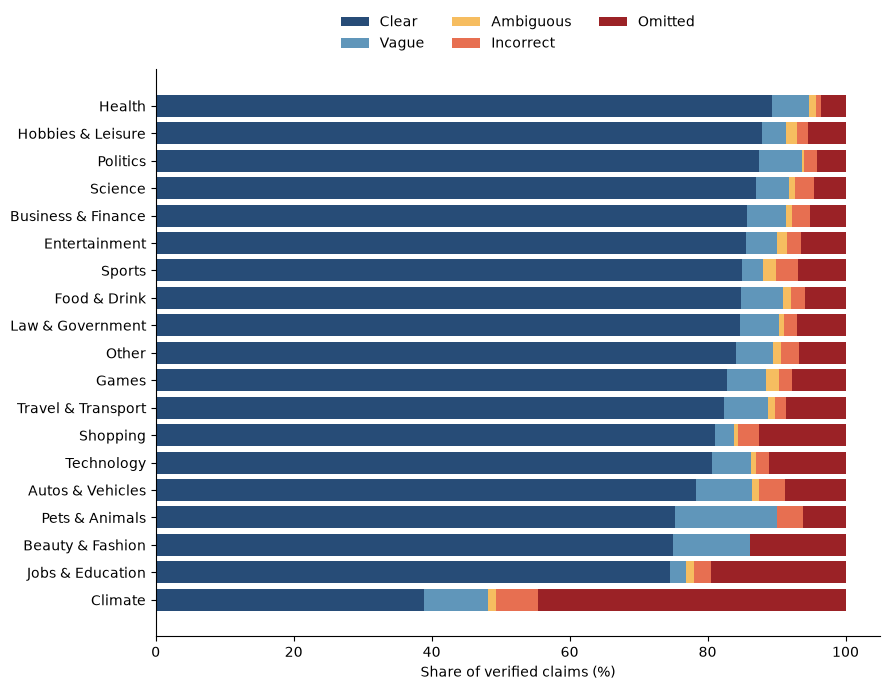

Category,Verified claims
Sports,"36,428"
Entertainment,"16,900"
Business & Finance,"11,082"
Science,"7,924"
Hobbies & Leisure,"6,399"
Other,"5,496"
Law & Government,"4,087"
Politics,"2,203"
Climate,"1,694"
Health,"1,454"


In [4]:
by_category = verifications.groupby("category")[LABELS].sum()
label_share = 100 * by_category.div(by_category.sum(axis=1), axis=0)
label_share = label_share.sort_values("CLEAR", ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
left = pd.Series(0.0, index=label_share.index)
colors = {"CLEAR":"#274c77", "VAGUE":"#6096ba", "AMBIGUOUS":"#f6bd60", "INCORRECT":"#e76f51", "OMITTED":"#9b2226"}
for label in LABELS:
    ax.barh(label_share.index, label_share[label], left=left, label=label.title(), color=colors[label])
    left += label_share[label]
ax.set_xlabel("Share of verified claims (%)")
ax.legend(ncol=3, frameon=False, loc="lower center", bbox_to_anchor=(0.5, 1.01))
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

figure5_counts = by_category.sum(axis=1).sort_values(ascending=False).reset_index()
figure5_counts.columns = ["Category", "Verified claims"]
show_table(figure5_counts, {"Verified claims":"{:,}"})

## UGC sensitivity

The submitted 5.3% estimate mixes two failure definitions. The table keeps the submitted calculation visible and also reports the two internally consistent calculations.

In [5]:
ugc = verifications[verifications["has_ugc"]]
narrow_all = int((verifications["INCORRECT"] + verifications["OMITTED"]).sum())
narrow_ugc = int((ugc["INCORRECT"] + ugc["OMITTED"]).sum())
broad_all = int((verifications["AMBIGUOUS"] + verifications["INCORRECT"] + verifications["OMITTED"]).sum())
broad_ugc = int((ugc["AMBIGUOUS"] + ugc["INCORRECT"] + ugc["OMITTED"]).sum())
assert (narrow_all, narrow_ugc, broad_all, broad_ugc) == (9_449, 5_658, 10_816, 6_360)
ugc_sensitivity = pd.DataFrame([
    ["Incorrect + Omitted", narrow_all, narrow_ugc, 100*(narrow_all-narrow_ugc)/total],
    ["Ambiguous + Incorrect + Omitted", broad_all, broad_ugc, 100*(broad_all-broad_ugc)/total],
    ["Submitted mixed calculation", broad_all, narrow_ugc, 100*(broad_all-narrow_ugc)/total],
], columns=["Definition", "All failures", "Failures in UGC-citing AIOs", "Residual / all judgments"])
show_table(ugc_sensitivity, {"All failures":"{:,}", "Failures in UGC-citing AIOs":"{:,}", "Residual / all judgments":"{:.2f}%"})

Definition,All failures,Failures in UGC-citing AIOs,Residual / all judgments
Incorrect + Omitted,"9,449","5,658",3.87%
Ambiguous + Incorrect + Omitted,"10,816","6,360",4.55%
Submitted mixed calculation,"10,816","5,658",5.26%


## Real-time-query sensitivity

In [6]:
excluded = pd.read_csv(ROOT / "replication" / "supporting" / "realtime_excluded_queries.csv")
excluded_counts = defaultdict(Counter)
for row in excluded.itertuples(index=False):
    excluded_counts[row.category].update(json.loads(row.label_counts))

category_counts = verifications.groupby("category")[LABELS].sum()
adjusted = []
for category in ["Technology", "Shopping", "Jobs & Education"]:
    counts = Counter(category_counts.loc[category].to_dict())
    counts.subtract(excluded_counts[category])
    n = sum(counts.values())
    rate = 100 * (counts["CLEAR"] + counts["VAGUE"]) / n
    adjusted.append([category, int((excluded["category"] == category).sum()), int(excluded.loc[excluded["category"] == category, "n_claims"].sum()), rate])
assert [(r[0],r[1],r[2],round(r[3],2)) for r in adjusted] == [("Technology",12,126,89.41),("Shopping",1,15,85.90),("Jobs & Education",12,107,87.71)]
show_table(pd.DataFrame(adjusted, columns=["Category", "Excluded AIOs", "Excluded claims", "Adjusted fidelity"]), {"Adjusted fidelity":"{:.2f}%"})

Category,Excluded AIOs,Excluded claims,Adjusted fidelity
Technology,12,126,89.41%
Shopping,1,15,85.90%
Jobs & Education,12,107,87.71%
